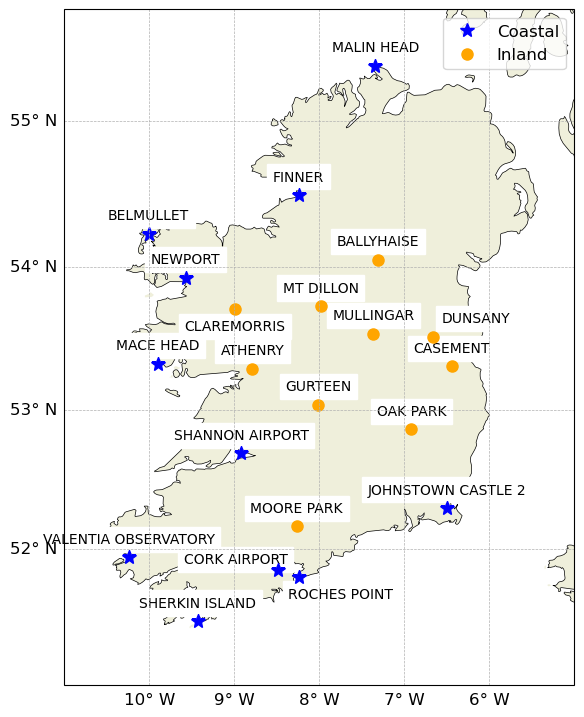

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

plt.rcParams.update({'font.size': 12})

# Define station categories
COASTAL_STATIONS = ['MC', 'SA', 'BT', 'RP', 'NT', 'MH', 'JC', 'FR', 'VO', 'SI', 'CT']
INLAND_STATIONS = ['AY', 'OP', 'MP', 'BE', 'MR', 'DY', 'GN', 'MD', 'CS', 'CA']

STNS = np.loadtxt("../DATA/Stations.txt", dtype='U2')
STN_LAT_LON = pd.read_csv("../DATA/Stations.csv", index_col=1)

# Filter the dataframe to only include coastal and inland stations
VALID_STATIONS = COASTAL_STATIONS + INLAND_STATIONS
STN_PLOT = STN_LAT_LON[STN_LAT_LON.index.isin(VALID_STATIONS)].copy()

LABEL_OFFSETS = {
    'CS': (-0.15, 0.0),
    'CT': (0.05, -0.5),
    'DY': (0.1, 0.5),
    'RP': (-0.15, 0.5),
}

if len(STNS) == 22:
    excluded_stations = [station for station in STNS if station not in VALID_STATIONS]
    if len(excluded_stations) == 1:
        LABEL_OFFSETS[excluded_stations[0]] = (0.0, 0.75)

STN_PLOT['lb_dlat'] = [LABEL_OFFSETS.get(station, (0.1, 0.0))[0] for station in STN_PLOT.index]
STN_PLOT['lb_dlon'] = [LABEL_OFFSETS.get(station, (0.1, 0.0))[1] for station in STN_PLOT.index]

# More compact size for 2-row paper layout
fig, ax = plt.subplots(1, 1, figsize=[6, 8], subplot_kw={"projection": ccrs.Mercator()})

ax.coastlines(resolution='10m', color='black', linewidth=0.5, zorder=0)
ax.set_extent([-11, -5, 51, 55.75])

# Create proxy artists for legend
coastal_marker = plt.Line2D([], [], color='b', marker='*', linestyle='None', markersize=10, label='Coastal')
inland_marker = plt.Line2D([], [], color='orange', marker='o', linestyle='None', markersize=8, label='Inland')

# Plot only valid stations
for i in range(len(STN_PLOT)):
    lon, lat = STN_PLOT.iloc[i].lon, STN_PLOT.iloc[i].lat
    station_code = STN_PLOT.iloc[i].name

    if station_code in COASTAL_STATIONS:
        ax.plot(lon, lat, 'b*', markersize=10, zorder=2, transform=ccrs.PlateCarree())
    elif station_code in INLAND_STATIONS:
        ax.plot(lon, lat, 'o', color='orange', markersize=8, zorder=2, transform=ccrs.PlateCarree())

    ax.text(
        lon + STN_PLOT.iloc[i].lb_dlon,
        lat + STN_PLOT.iloc[i].lb_dlat,
        STN_PLOT.iloc[i].station_name,
        horizontalalignment='center',
        fontsize=10,  
        zorder=1,
        transform=ccrs.PlateCarree(),
        backgroundcolor="white"
    )

ax.add_feature(cfeature.LAND)

grd = ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.5)
grd.top_labels = False
grd.right_labels = False
grd.xlabel_style = {'size': 12}
grd.ylabel_style = {'size': 12}

grd.xformatter = LongitudeFormatter(degree_symbol='° ')
grd.yformatter = LatitudeFormatter(degree_symbol='° ')

# Legend
ax.legend(handles=[coastal_marker, inland_marker], loc='upper right', fontsize=12)

plt.tight_layout()
plt.savefig("ET4I_Spatial.png", dpi=300)
plt.show()